Import bibliotek

In [23]:
import pandas as pd
import numpy as nb
import matplotlib.pyplot as plt
import seaborn as sns

Wczytanie danuch

In [16]:
df_customers = pd.read_csv('dane/olist_customers_dataset.csv')
df_geolocation = pd.read_csv('dane/olist_geolocation_dataset.csv')
df_order_items = pd.read_csv('dane/olist_order_items_dataset.csv')
df_order_payments = pd.read_csv('dane/olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv('dane/olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('dane/olist_orders_dataset.csv')
df_products = pd.read_csv('dane/olist_products_dataset.csv')
df_sellers = pd.read_csv('dane/olist_sellers_dataset.csv')
df_category_names = pd.read_csv('dane/product_category_name_translation.csv')

In [17]:
print(df_customers.head())
print(df_geolocation.head())
print(df_order_items.head())
print(df_order_payments.head())
print(df_order_reviews.head())
print(df_orders.head())
print(df_products.head())
print(df_sellers.head())
print(df_category_names.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                

Łącznie danych

In [18]:
df = df_orders.merge(df_customers, on='customer_id', how='left')
df = df.merge(df_order_items, on='order_id', how='left')
df = df.merge(df_products, on='product_id', how='left')
df = df.merge(df_sellers, on='seller_id', how='left')
df = df.merge(df_order_payments, on='order_id', how='left')
df = df.merge(df_order_reviews, on='order_id', how='left')
df = df.merge(df_category_names, on='product_category_name', how='left')
df = df.merge(df_geolocation[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']].drop_duplicates('geolocation_zip_code_prefix'),
              left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')

print("Kształt połączonego df:", df.shape)
print(df.head())

Kształt połączonego df: (119143, 43)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          

In [19]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [20]:
df.isna().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


In [21]:
df = df.dropna()

In [22]:
df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
seller_zip_code_prefix           0
seller_city                      0
seller_state        

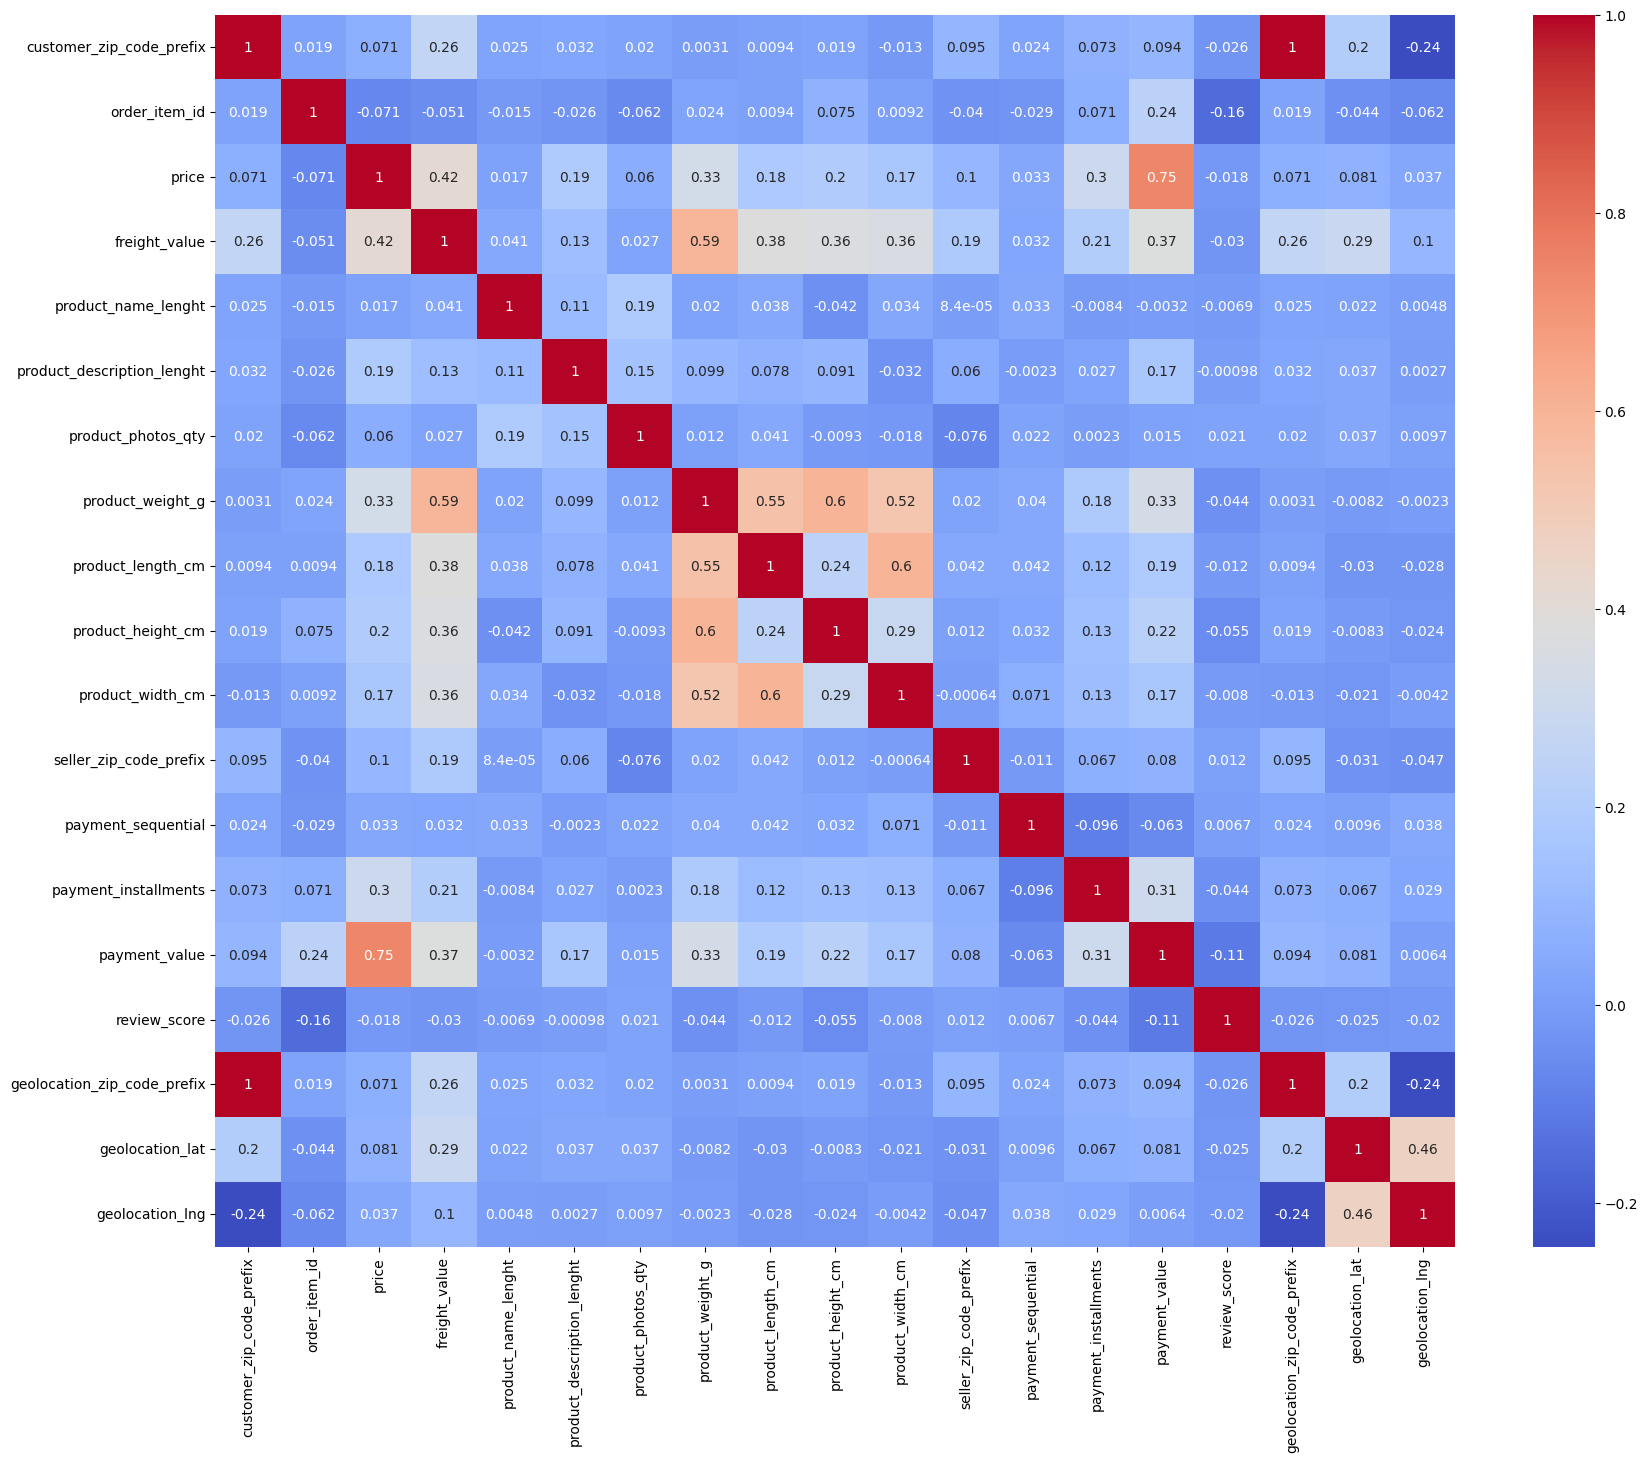

In [26]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(20,16))
sns.heatmap(numeric_df.corr(), annot=True, cmap ='coolwarm')
plt.show()